In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

final_labels = pd.read_csv("final_labels.csv")

In [2]:
contingency_model = pd.crosstab(
    final_labels["model"],
    final_labels["label"]
)

print(contingency_model)

label              0   1
model                   
dalle             76  29
midjourney        90  11
stable_diffusion  48  29


In [12]:
chi2, p, dof, expected = chi2_contingency(contingency_model)

print("Chi-square statistic:", chi2)
print("p-value:", p)


Chi-square statistic: 17.932971624207177
p-value: 0.0001276158712305909


In [4]:
n = contingency_model.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_model.shape)-1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.2517288042681222


In [5]:
residuals_model = (
    contingency_model - expected
) / np.sqrt(expected)

residuals_model = pd.DataFrame(
    residuals_model,
    index=contingency_model.index,
    columns=contingency_model.columns
)

residuals_model = residuals_model.rename(
    columns={0: "Male", 1: "Female"}
)


print(residuals_model)

label                 Male    Female
model                               
dalle            -0.381488  0.671835
midjourney        1.559108 -2.745735
stable_diffusion -1.340149  2.360127


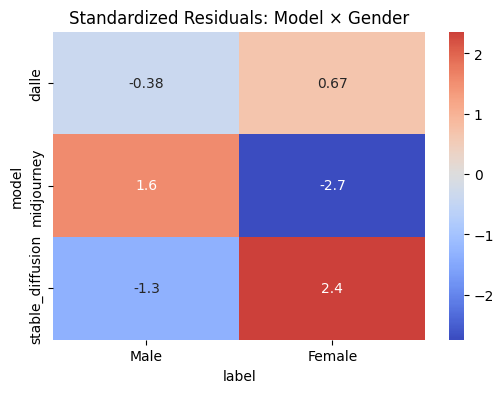

In [6]:
plt.figure(figsize=(6,4))

sns.heatmap(
    residuals_model,
    annot=True,
    cmap="coolwarm",
    center=0
)


plt.title("Standardized Residuals: Model × Gender")
plt.show()

In [7]:
contingency_bank = pd.crosstab(
    final_labels["bank"],
    final_labels["label"]
)

chi2_p, p_p, dof_p, expected_p = chi2_contingency(contingency_bank)

print("Chi-square statistic:", chi2_p)
print("p-value:", p_p)


Chi-square statistic: 3.5744234622846833
p-value: 0.46665268437907104


In [8]:
n = contingency_bank.sum().sum()
cramers_v = np.sqrt(chi2_p / (n * (min(contingency_bank.shape)-1)))

print("Cramér's V:", cramers_v)


Cramér's V: 0.11238537092601997


In [9]:
residuals_profession = (
    contingency_bank - expected_p
) / np.sqrt(expected_p)

residuals_bank = pd.DataFrame(
    residuals_profession,
    index=contingency_bank.index,
    columns=contingency_bank.columns
)

residuals_bank = residuals_bank.rename(
    columns={0: "Male", 1: "Female"}
)


print(residuals_bank)


label            Male    Female
bank                           
BofA         0.218621 -0.385012
Citibank    -0.129656  0.228336
JPMorgan     0.631749 -1.112569
US          -0.131598  0.231757
Wells_Fargo -0.624877  1.100467


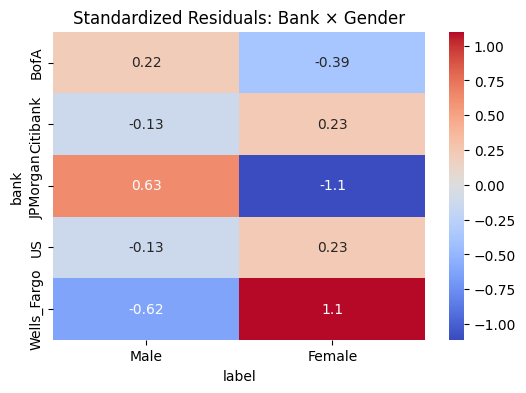

In [13]:
plt.figure(figsize=(6,4))

sns.heatmap(
    residuals_bank,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Bank × Gender")
plt.show()